Importing Libraries and Global Modules

In [1]:
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from typing import TypedDict, List, Dict, NotRequired, Literal
from langgraph.graph import StateGraph, END
from langgraph.types import interrupt

In [2]:
import os
import sys
sys.path.append(os.path.abspath(".."))

In [3]:
from agent.llm import call_llm, call_structured_llm
from agent.states import GlobalState

### Elicitation Stage
1. Requirement Specification Node: Extracts requirements and constriants, and stores missing details in `unknowns`.
3. Clarification Node: Turns `unknowns` into short follow-up questions for the user.

In [4]:
# ======== Elicitation Graph States ========

class ElicitationState(GlobalState):
    unknowns: List[Dict[str, str]]
    clarified_answers: NotRequired[Dict[str, str]]

In [ ]:
# ========= Requirement Specification Node =========

class UnknownItem(BaseModel):
    field: str
    input_type: Literal["string", "list"]

# Define structured output schema for requirement extraction
class RequirementDetails(BaseModel):
    problem_statement: str = ""
    target_users: List[str] = []
    core_features: List[str] = []
    user_actions: List[str] = []  # what users actually do
    entities: List[str] = []  # main objects (order, user, product, etc.)
    scale_hint: str = ""
    domain: str = ""
    
# Define structured output schema for constraints extraction
class ConstraintDetails(BaseModel):
    scale: str = ""
    latency: str = ""
    availability: str = ""
    consistency: str = ""
    budget: str = ""
    team_size: str = ""
    security: str = ""

class RequirementSpecification(BaseModel):
    requirements: RequirementDetails
    constraints: ConstraintDetails
    unknowns: List[UnknownItem] = []

# Prompt template for requirement and constraint extraction
requirement_specs_prompt = PromptTemplate.from_template(
    """Extract only structured product requirements and system constraints.

Rules:
- Use ONLY given input and clarified answers (if any).
- If missing, add to unknowns with field + input_type
- Keep outputs concise and specific
- Assume values only if stated indirectly in the input
  (e.g., "like X" implies similar scale/features, "must be fast" implies low latency, etc.)
- Prefer explicit values over vague texts.

Input:
{user_input}

Clarified Answers:
{clarified_answers}"""
)

# Helper function to infer unknowns from empty fields in requirements/constraints
def unkowns_inference(data: Dict, unknowns: List[Dict[str, str]]):
    unknown_fields = {item["field"] for item in unknowns}
    
    for key, value in data.items():
        if (not value or (isinstance(value, list) and len(value) == 0)) and key not in unknown_fields:
            input_type = "list" if isinstance(value, list) else "string"
            unknowns.append({
				"field": key,
				"input_type": input_type
			})

# Node function for requirement extraction
def requirement_specs_node(state: ElicitationState) -> Dict:
    user_input = state["user_input"]
    clarified_answers = state.get("clarified_answers", {})
    
    prompt = requirement_specs_prompt.format(
        user_input=user_input,
        clarified_answers=clarified_answers
    )

    result = call_structured_llm(RequirementSpecification, prompt)
    requirements = result.get("requirements", {})
    constraints = result.get("constraints", {})
    unknowns = result.get("unknowns", [])

    # Fallback: infer missing keys if the model returns an empty unknowns list.
    unkowns_inference(requirements, unknowns)
    unkowns_inference(constraints, unknowns)
    
	# Clear unknowns if we had clarified answers, to avoid infinite clarification loops - Only 1 round of clarification
    new_unknowns = unknowns if not clarified_answers else []

    return {
        "requirements": requirements,
        "constraints": constraints,
        "unknowns": new_unknowns,
        "clarified_answers": {}
    }

In [6]:
# Example usage
requirement_specs_node({
    "user_input": "I want to build food delivery app like Zomato, but for local restaurants in my city. It should allow users to browse menus, place orders, and track deliveries."
})

{'requirements': {'problem_statement': '',
  'target_users': ['users', 'local restaurants'],
  'core_features': ['menu browsing', 'order placement', 'delivery tracking'],
  'user_actions': ['browse menus', 'place orders', 'track deliveries'],
  'entities': [],
  'scale_hint': 'like Zomato',
  'domain': 'food delivery'},
 'constraints': {'scale': '',
  'latency': '',
  'availability': '',
  'consistency': '',
  'budget': '',
  'team_size': '',
  'security': ''},
 'unknowns': [{'field': 'entities', 'input_type': 'list'},
  {'field': 'problem_statement', 'input_type': 'string'},
  {'field': 'scale', 'input_type': 'string'},
  {'field': 'latency', 'input_type': 'string'},
  {'field': 'availability', 'input_type': 'string'},
  {'field': 'consistency', 'input_type': 'string'},
  {'field': 'budget', 'input_type': 'string'},
  {'field': 'team_size', 'input_type': 'string'},
  {'field': 'security', 'input_type': 'string'}],
 'clarified_answers': {}}

In [9]:
# ======== Clarification Question Generation Node =========

# # Define structured output schema for clarification questions
# class ClarificationOutput(BaseModel):
#     questions: List[str] = Field(default_factory=list)
    
# # Prompt template for generating clarification questions
# clarification_prompt = PromptTemplate.from_template(
#     """You are a senior system design analyst.
# Generate concise clarification questions from the unknowns list.

# If unknowns is empty, return an empty questions list.

# Unknowns:
# {unknowns}"""
# )

# Node function for generating clarification questions
def clarification_node(state: ElicitationState) -> Dict:
	unknowns = state.get("unknowns", [])
	clarified_answers = state.get("clarified_answers", {})

	if len(unknowns) == 0:
		return {
			"clarified_answers": {}  # No clarification needed
		}

	# prompt = clarification_prompt.format(unknowns=unknowns)
	# result = call_structured_llm(ClarificationOutput, prompt)

	# Use the questions to prompt the user for answers.
	answers = {}
	for question in unknowns:
		field, input_type = question["field"], question["input_type"]
		answer = clarified_answers.get(field, "")
		if answer != "":
			answers[field] = answer
		else:
			answers[field] = input(f"{field}: ") or ""

	return {
		"clarified_answers": answers
	}

In [10]:
# Example usage
clarification_node({
    "unknowns": [
       { "field": "latency", "input_type": "string"},
	   { "field": "team_size", "input_type": "string"},
	]
})

{'clarified_answers': {'latency': '', 'team_size': ''}}

In [11]:
# ======== Elicitation Router Nodes =========
def clarification_router(state: ElicitationState):
    unknowns = state.get("unknowns", [])
    # If there are unknowns, go to the clarification node.
    if len(unknowns) > 0:
        return "clarify"
    
    # If there are no unknowns, we can end elicitation or move to the next phase.
    return END

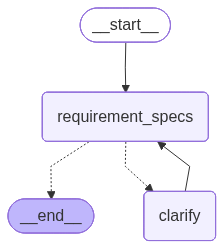

In [14]:
# ======== Graph Construction ========

elicitation_graph = StateGraph(ElicitationState)

elicitation_graph.add_node("requirement_specs", requirement_specs_node)
elicitation_graph.add_node("clarify", clarification_node)

elicitation_graph.add_conditional_edges(
    "requirement_specs",
    clarification_router,
    {
        "clarify": "clarify",
        END: END
    }
)

elicitation_graph.set_entry_point("requirement_specs")
elicitation_graph.add_edge("clarify", "requirement_specs")

elicitation_stage = elicitation_graph.compile()
elicitation_stage

In [15]:
# Example usage of the elicitation stage
elicitation_stage.invoke({
    "user_input": "I want to build a social media app for pet owners. It should allow users to create profiles for their pets, share photos, and connect with other pet owners. Initially, we expect around 10,000 daily active users."
})

{'user_input': 'I want to build a social media app for pet owners. It should allow users to create profiles for their pets, share photos, and connect with other pet owners. Initially, we expect around 10,000 daily active users.',
 'requirements': {'problem_statement': 'social media app',
  'target_users': ['pet owners'],
  'core_features': ['Create profiles for pets',
   'Share photos',
   'Connect with other pet owners',
   'Like/share/comment posts',
   'Message others'],
  'user_actions': ['auth',
   'create profiles',
   'share photos',
   'connect with other',
   'like/share/comment posts',
   'message others'],
  'entities': ['user', 'posts', 'media'],
  'scale_hint': '10,000 daily active users',
  'domain': 'social media app for pet owners'},
 'constraints': {'scale': 'high',
  'latency': 'medium',
  'availability': 'not decided',
  'consistency': 'medium',
  'budget': '100$',
  'team_size': '5',
  'security': 'medium'},
 'unknowns': [],
 'clarified_answers': {}}